# 3 Qubit Search

# Project 6: Grover's Search (3-Qubit Scaling)

**Objective:** Scale Grover's Algorithm to a 3-qubit system ($N=8$ items) to find the hidden state `101`. 

**Theory: Optimal Iterations**
In our 2-qubit ($N=4$) search, one pass through the Oracle and Diffuser yielded a 100% probability. However, as the database grows, one pass is no longer enough. The optimal number of iterations $k$ required to maximize the probability of finding the target state is approximated by the formula:

$$k \approx \frac{\pi}{4} \sqrt{N}$$

For 3 qubits, $N = 2^3 = 8$. 
$$k \approx \frac{\pi}{4} \sqrt{8} \approx 2.22$$

This dictates that we must run the [Oracle + Diffuser] block **twice** to achieve the highest possible probability (~94.5%). If we only ran it once, our probability of success would only be ~78%.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display
import math

print("Environment Ready.")

Environment Ready.


## Step 1: The Oracle (Targeting `101`)

To target the specific state `101` (where Qubit 2 is `1`, Qubit 1 is `0`, and Qubit 0 is `1`), we must apply a phase flip *only* when the qubits are in this configuration. 

Because the native multi-controlled phase gate (CCZ) triggers when all controls are `1`, we must mathematically "trick" the gate by placing $X$ gates around the `0` values. 
1. Apply $X$ to Qubit 1 (turning our `101` state temporarily into `111`).
2. Apply a CCZ gate. (We construct a CCZ by wrapping a standard CCX/Toffoli gate in Hadamard gates: $H \cdot X \cdot H = Z$).
3. Apply $X$ back to Qubit 1 to reverse the temporary change.

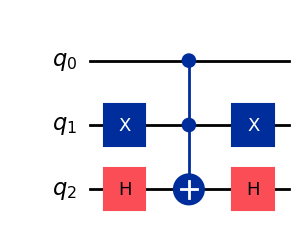

In [2]:
def grover_oracle_101() -> QuantumCircuit:
    """An oracle that flips the phase of the |101> state."""
    qc = QuantumCircuit(3, name="Oracle (101)")
    
    # 1. Flip Qubit 1 so the target state temporarily looks like |111>
    qc.x(1)
    
    # 2. Apply CCZ (Controlled-Controlled-Z)
    # We build a CCZ using a CCX (Toffoli) sandwiched by H gates on the target
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    
    # 3. Uncompute Qubit 1
    qc.x(1)
    
    return qc

display(grover_oracle_101().draw('mpl'))

## Step 2: The 3-Qubit Diffuser

The Diffuser must also be scaled up to handle 3 qubits. The architecture remains the same as the 2-qubit version, but now applies the reflection across all 3 wires using a CCZ gate in the center.

1. $H$ gates on all 3 qubits.
2. $X$ gates on all 3 qubits.
3. CCZ gate on all 3 qubits (Reflection).
4. $X$ gates on all 3 qubits.
5. $H$ gates on all 3 qubits.

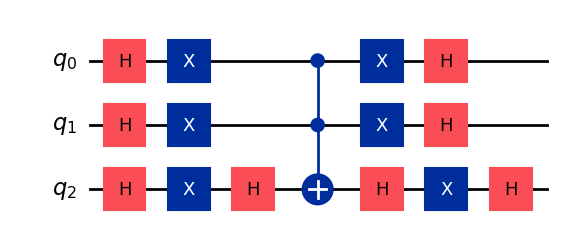

In [3]:
def grover_diffuser_3q() -> QuantumCircuit:
    """Constructs the standard Grover diffuser for 3 qubits."""
    qc = QuantumCircuit(3, name="Diffuser")
    
    qc.h([0, 1, 2])
    qc.x([0, 1, 2])
    
    # Multi-controlled Z (CCZ)
    qc.h(2)
    qc.ccx(0, 1, 2)
    qc.h(2)
    
    qc.x([0, 1, 2])
    qc.h([0, 1, 2])
    
    return qc

display(grover_diffuser_3q().draw('mpl'))

## Step 3: Full Algorithm & Execution

We now assemble the algorithm. Crucially, we will use a `for` loop to apply the Oracle and Diffuser exactly **2 times**, matching our mathematical calculation for the optimal number of iterations.

Full 3-Qubit Grover's Search Circuit (2 Iterations):


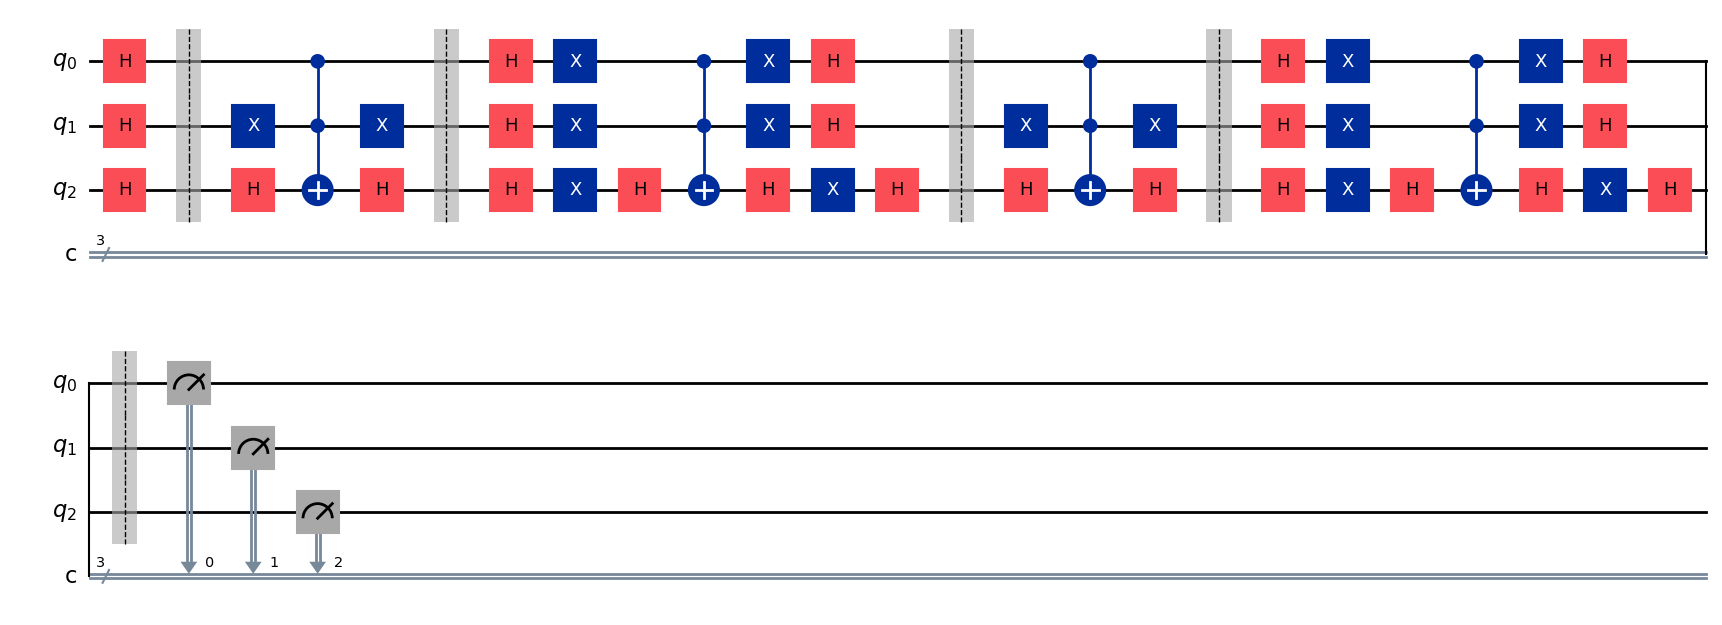


Search Output: {'101': 961, '111': 8, '110': 7, '011': 5, '100': 8, '000': 8, '010': 15, '001': 12}


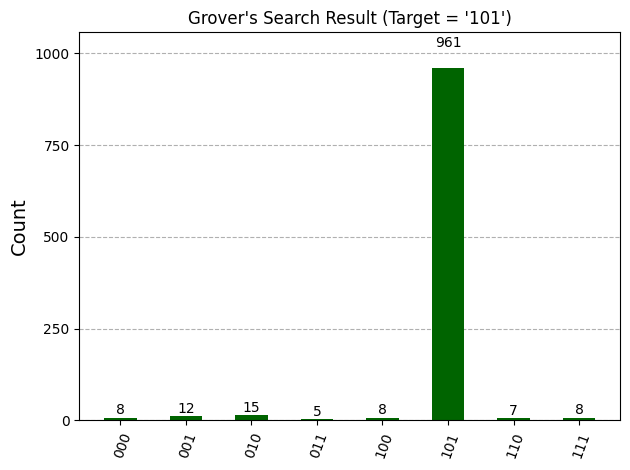

In [4]:
def run_grovers_3_qubit() -> QuantumCircuit:
    """Constructs and executes the 3-qubit Grover's Search."""
    qc = QuantumCircuit(3, 3)
    
    # 1. Initialize uniform superposition
    qc.h([0, 1, 2])
    qc.barrier()
    
    # 2. Optimal Iterations Loop (2 times for N=8)
    optimal_iterations = 2
    for _ in range(optimal_iterations):
        # Append Oracle
        qc.compose(grover_oracle_101(), inplace=True)
        qc.barrier()
        
        # Append Diffuser
        qc.compose(grover_diffuser_3q(), inplace=True)
        qc.barrier()
        
    # 3. Measure
    qc.measure([0, 1, 2], [0, 1, 2])
    
    return qc

# Build the complete circuit
grover_circuit = run_grovers_3_qubit()

# Display the full circuit architecture
print("Full 3-Qubit Grover's Search Circuit (2 Iterations):")
display(grover_circuit.draw('mpl'))

# Initialize the V2 Sampler and execute
sampler = StatevectorSampler()
job = sampler.run([grover_circuit], shots=1024)
pub_result = job.result()[0]

# Extract counts from the classical register
counts = pub_result.data.c.get_counts()

print(f"\nSearch Output: {counts}")

# Verify the massive probability spike on the state '101'
display(plot_histogram(counts, title="Grover's Search Result (Target = '101')", color='darkgreen'))